In [1]:
%matplotlib inline
import os
import timeit
import warnings

import matplotlib.pyplot as plt
import numpy as np

import jaxqsofit
from astropy.io import fits

warnings.filterwarnings("ignore")

path_ex = '.'



In [2]:
"""
Line-prior table in plain Python dictionaries (no HDU/FITS priors).
"""

LINE_COLUMNS = [
    'lambda', 'compname', 'minwav', 'maxwav', 'linename', 'ngauss',
    'inisca', 'minsca', 'maxsca', 'inisig', 'minsig', 'maxsig',
    'voff', 'vindex', 'windex', 'findex', 'fvalue', 'vary',
]

LINE_DTYPE = [
    ('lambda', 'f8'), ('compname', 'U16'), ('minwav', 'f8'), ('maxwav', 'f8'),
    ('linename', 'U32'), ('ngauss', 'i4'), ('inisca', 'f8'), ('minsca', 'f8'),
    ('maxsca', 'f8'), ('inisig', 'f8'), ('minsig', 'f8'), ('maxsig', 'f8'),
    ('voff', 'f8'), ('vindex', 'i4'), ('windex', 'i4'), ('findex', 'i4'),
    ('fvalue', 'f8'), ('vary', 'i4'),
]

line_prior_rows = [
    # Halpha complex
    {'lambda': 6564.61, 'compname': 'Ha', 'minwav': 6400, 'maxwav': 6800, 'linename': 'Ha_br', 'ngauss': 2, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.015, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.05, 'vary': 1},
    {'lambda': 6564.61, 'compname': 'Ha', 'minwav': 6400, 'maxwav': 6800, 'linename': 'Ha_na', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 5e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.002, 'vary': 1},
    {'lambda': 6549.85, 'compname': 'Ha', 'minwav': 6400, 'maxwav': 6800, 'linename': 'NII6549', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 5e-3, 'vindex': 1, 'windex': 1, 'findex': 1, 'fvalue': 0.001, 'vary': 1},
    {'lambda': 6585.28, 'compname': 'Ha', 'minwav': 6400, 'maxwav': 6800, 'linename': 'NII6585', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 5e-3, 'vindex': 1, 'windex': 1, 'findex': 1, 'fvalue': 0.003, 'vary': 1},
    {'lambda': 6718.29, 'compname': 'Ha', 'minwav': 6400, 'maxwav': 6800, 'linename': 'SII6718', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 5e-3, 'vindex': 1, 'windex': 1, 'findex': 2, 'fvalue': 0.001, 'vary': 1},
    {'lambda': 6732.67, 'compname': 'Ha', 'minwav': 6400, 'maxwav': 6800, 'linename': 'SII6732', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 5e-3, 'vindex': 1, 'windex': 1, 'findex': 2, 'fvalue': 0.001, 'vary': 1},

    # Hbeta / [OIII]
    {'lambda': 4862.68, 'compname': 'Hb', 'minwav': 4640, 'maxwav': 5100, 'linename': 'Hb_br', 'ngauss': 2, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.01, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.01, 'vary': 1},
    {'lambda': 4862.68, 'compname': 'Hb', 'minwav': 4640, 'maxwav': 5100, 'linename': 'Hb_na', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.002, 'vary': 1},
    {'lambda': 4960.30, 'compname': 'Hb', 'minwav': 4640, 'maxwav': 5100, 'linename': 'OIII4959c', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.002, 'vary': 1},
    {'lambda': 5008.24, 'compname': 'Hb', 'minwav': 4640, 'maxwav': 5100, 'linename': 'OIII5007c', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.004, 'vary': 1},
    {'lambda': 4960.30, 'compname': 'Hb', 'minwav': 4640, 'maxwav': 5100, 'linename': 'OIII4959w', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 3e-3, 'minsig': 2.3e-4, 'maxsig': 0.004, 'voff': 0.01, 'vindex': 2, 'windex': 2, 'findex': 0, 'fvalue': 0.001, 'vary': 1},
    {'lambda': 5008.24, 'compname': 'Hb', 'minwav': 4640, 'maxwav': 5100, 'linename': 'OIII5007w', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 3e-3, 'minsig': 2.3e-4, 'maxsig': 0.004, 'voff': 0.01, 'vindex': 2, 'windex': 2, 'findex': 0, 'fvalue': 0.002, 'vary': 1},

    # Higher-order Balmer
    {'lambda': 4341.68, 'compname': 'Hg', 'minwav': 4200, 'maxwav': 4400, 'linename': 'Hg_br', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.01, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.01, 'vary': 1},
    {'lambda': 4341.68, 'compname': 'Hg', 'minwav': 4200, 'maxwav': 4400, 'linename': 'Hg_na', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.002, 'vary': 1},
    {'lambda': 4102.89, 'compname': 'Hd', 'minwav': 4000, 'maxwav': 4150, 'linename': 'Hd_br', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.01, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.01, 'vary': 1},
    {'lambda': 4102.89, 'compname': 'Hd', 'minwav': 4000, 'maxwav': 4150, 'linename': 'Hd_na', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 2.3e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.002, 'vary': 1},

    # Other optical/UV lines
    {'lambda': 3728.48, 'compname': 'OII', 'minwav': 3650, 'maxwav': 3800, 'linename': 'OII3728', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 3.333e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.001, 'vary': 1},
    {'lambda': 3426.84, 'compname': 'NeV', 'minwav': 3380, 'maxwav': 3480, 'linename': 'NeV3426', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 3.333e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.001, 'vary': 1},

    {'lambda': 2798.75, 'compname': 'MgII', 'minwav': 2700, 'maxwav': 2900, 'linename': 'MgII_br', 'ngauss': 2, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.015, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.05, 'vary': 1},
    {'lambda': 2798.75, 'compname': 'MgII', 'minwav': 2700, 'maxwav': 2900, 'linename': 'MgII_na', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 1e-3, 'minsig': 5e-4, 'maxsig': 0.00169, 'voff': 0.01, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.002, 'vary': 1},

    {'lambda': 1908.73, 'compname': 'CIII', 'minwav': 1700, 'maxwav': 1970, 'linename': 'CIII_br', 'ngauss': 2, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.015, 'vindex': 99, 'windex': 0, 'findex': 0, 'fvalue': 0.01, 'vary': 1},

    {'lambda': 1549.06, 'compname': 'CIV', 'minwav': 1500, 'maxwav': 1700, 'linename': 'CIV_br', 'ngauss': 2, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.004, 'maxsig': 0.05, 'voff': 0.015, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.05, 'vary': 1},

    {'lambda': 1402.06, 'compname': 'SiIV', 'minwav': 1290, 'maxwav': 1450, 'linename': 'SiIV_OIV1', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.002, 'maxsig': 0.05, 'voff': 0.015, 'vindex': 1, 'windex': 1, 'findex': 0, 'fvalue': 0.05, 'vary': 1},

    {'lambda': 1215.67, 'compname': 'Lya', 'minwav': 1150, 'maxwav': 1290, 'linename': 'Lya_br', 'ngauss': 3, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 5e-3, 'minsig': 0.002, 'maxsig': 0.05, 'voff': 0.02, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.05, 'vary': 1},
    {'lambda': 1240.14, 'compname': 'Lya', 'minwav': 1150, 'maxwav': 1290, 'linename': 'NV1240', 'ngauss': 1, 'inisca': 0.0, 'minsca': 0.0, 'maxsca': 1e10, 'inisig': 2e-3, 'minsig': 0.001, 'maxsig': 0.01, 'voff': 0.005, 'vindex': 0, 'windex': 0, 'findex': 0, 'fvalue': 0.002, 'vary': 1},
]


def line_rows_to_recarray(rows):
    """Convert list-of-dicts line prior rows to the structured array expected by jaxqsofit."""
    vals = [tuple(row[k] for k in LINE_COLUMNS) for row in rows]
    return np.array(vals, dtype=LINE_DTYPE)


line_priors = line_rows_to_recarray(line_prior_rows)
print(f"Loaded {len(line_priors)} line-prior rows")



Loaded 25 line-prior rows


In [3]:
# Requried
#data = fits.open(os.path.join('../isaque_pyqsofit/example', 'data/spec-0332-52367-0639.fits'))
#data = fits.open(os.path.join('../isaque_pyqsofit/example', 'data/spec-0266-51602-0107.fits'))

data = fits.open(os.path.join('../isaque_pyqsofit/example', 'data/spec-4209-55478-0815.fits'))

#
lam = 10 ** data[1].data['loglam']  # OBS wavelength [A]
flux = data[1].data['flux']  # OBS flux [erg/s/cm^2/A]
err = 1 / np.sqrt(data[1].data['ivar'])  # 1 sigma error
z = data[2].data['z'][0]  # Redshift

# Optional
ra = data[0].header['plug_ra']  # RA
dec = data[0].header['plug_dec']  # DEC
plateid = data[0].header['plateid']  # SDSS plate ID
mjd = data[0].header['mjd']  # SDSS MJD
fiberid = data[0].header['fiberid']  # SDSS fiber ID

In [4]:
lam[lam>(1200*(1+z))]

array([ 5360.433 ,  5361.6694,  5362.903 , ..., 10370.507 , 10372.898 ,
       10375.279 ], shape=(2869,), dtype=float32)

In [ ]:
# Prepare data
q_mle = jaxqsofit.QSOFit(
    lam[lam>(1200*(1+z))],
    flux[lam>(1200*(1+z))],
    err[lam>(1200*(1+z))],
    z,
    ra=ra,
    dec=dec,
    plateid=plateid,
    mjd=mjd,
    fiberid=fiberid,
    path=path_ex,
)
print(flux)
fscale = float(np.nanmedian(np.abs(flux)))  # ~50 for this target
fmax = float(np.nanmax(np.abs(flux)))

# Sanitize line priors so amplitudes/widths cannot explode
line_priors_use = line_priors.copy()
comp = np.char.lower(np.asarray(line_priors_use['compname']).astype(str))
is_broad = np.char.find(comp, 'br') >= 0

line_priors_use['maxsca'][~is_broad] = np.minimum(line_priors_use['maxsca'][~is_broad], 1.2*(fmax - fscale))
line_priors_use['maxsca'][is_broad] = np.minimum(line_priors_use['maxsca'][is_broad], 1.0*(fmax - fscale))

# Keep initial scales inside [min, max] and away from zero
line_priors_use['minsca'] = np.maximum(line_priors_use['minsca'], 1e-4 * fscale)
line_priors_use['inisca'] = np.clip(line_priors_use['inisca'], line_priors_use['minsca'], line_priors_use['maxsca'])

# All priors explicit in notebook (no global scaling priors)
prior_config = {
    # Power law
    'log_cont_norm': {'loc': np.log(max(fscale, 1e-8)), 'scale': 0.3},
    'PL_slope': {'loc': -1.5, 'scale': 4, 'low': -3.5, 'high': 0.3},
    # FeII (used only when fit_fe=True)
    'log_Fe_uv_norm': {'loc': np.log(max(0.01 * fscale, 1e-8)), 'scale': 0.3},
    'log_Fe_op_norm': {'loc': np.log(max(0.01 * fscale, 1e-8)), 'scale': 0.3},
    'log_Fe_uv_FWHM': {'loc': np.log(3000.0), 'scale': 0.3},
    'log_Fe_op_FWHM': {'loc': np.log(3000.0), 'scale': 0.3},
    'Fe_uv_shift': {'loc': 0.0, 'scale': 0.001},
    'Fe_op_shift': {'loc': 0.0, 'scale': 0.001},
    # Balmer continuum (used only when fit_bc=True)
    'log_Balmer_norm': {'loc': np.log(max(0.01 * fscale, 1e-8)), 'scale': 0.5},
    'Balmer_Te': {'loc': 15000.0, 'scale': 1500.0},
    'log_Balmer_Tau': {'loc': np.log(0.5), 'scale': 0.25},
    'log_Balmer_vel': {'loc': np.log(3000.0), 'scale': 0.25},
    # Host (used only when decompose_host=True)
    'tau_host': {'scale': 1.0},
    'raw_w': {'loc': -0.5, 'scale': 1.0},
    'log_frac_host': {'loc': 3.0, 'scale': 2.0},
    'gal_v_kms': {'loc': 0.0, 'scale': 120.0},
    'gal_sigma_kms': {'scale': 200.0},
    # Noise
    'frac_jitter': {'scale': 0.02},
    'add_jitter': {'scale_mult_err': 0.3},
    # Line-group prior widths (relative to table bounds)
    'line_dmu_scale_mult': 0.25,
    'line_sig_scale_mult': 0.25,
    'line_amp_scale_mult': 0.25,
    # Emission-line table
    'line': {
        'table': line_priors_use,
    },
    # Optional polynomial (used only when fit_poly=True)
    'poly_c1': {'loc': 0.0, 'scale': 0.1},
    'poly_c2': {'loc': 0.0, 'scale': 0.1},
}

# Fitting
start = timeit.default_timer()
q_mle.Fit(
    name=None,
    deredden=True,
    wave_range=None,
    wave_mask=None,
    fit_lines=True,
    decompose_host=True,
    fit_fe=True,
    fit_bc=True,
    fit_poly=True,
    save_result=False,
    save_fits_name=None,
    save_fits_path='.',
    plot_fig=True,
    save_fig=False,
    verbose=True,
    fsps_age_grid=(0.1, 0.3, 1.0, 3.0, 10.0),
    fsps_logzsol_grid=(-1.0, -0.5, 0.0, 0.2),
    prior_config=prior_config,
    dsps_ssp_fn='tempdata.h5',
    nuts_warmup=200,
    nuts_samples=20,
    nuts_chains=1,
    nuts_target_accept=0.8,
    kwargs_plot={
        'save_fig_path': '.',
        'broad_fwhm': 1200,
        'full_posterior': False,
        'plot_trace': True,
        'plot_corner': False,
        'max_corner_dims': 0,
        'max_vector_elems': -1,
        'plot_1sigma': True,
        'sigma_alpha': 0.8,
    },
)
end = timeit.default_timer()
print(f'Fitting finished in {np.round(end - start, 1)}s')


[ 3.6360278  -1.9883697  -2.7132802  ...  0.6566976  -0.90782917
 -2.47235   ]


In [ ]:
q_mle.frac_host_2500

-1.0

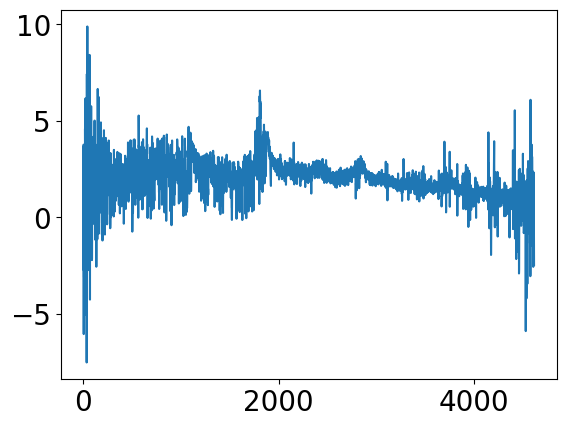

In [ ]:
plt.plot(flux)